# Stage 1 — subject retrieval across LOSO folds

This notebook reproduces the thesis retrieval figure. Panel A summarizes Top-1 subject retrieval accuracy over all 154 held-out subjects. Panel B compares each fold's mean within-subject distance with its nearest-other-subject distance; points above the diagonal have a positive retrieval margin.

In [1]:
from pathlib import Path
import os
import subprocess
import os, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Start Jupyter from final_refactored; all project paths are relative to it.
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').is_file():  # VS Code may start in notebooks/
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').is_file():
    raise RuntimeError('Open this notebook from final_refactored or its notebooks folder.')
os.chdir(ROOT)
# Reuse the active notebook kernel; this stays portable after cloning.
PROJECT_PYTHON = Path(sys.executable)

EXPERIMENT = 'relat_cons_32'  # change to relat_cons_16 to inspect 16-D representations
DATA_DIR = Path('data/raw/stage1')
RESULT_ROOT = Path('artifacts/stage1')
ANALYSIS_DIR = Path('results/tables/stage1') / f'full_grid_{EXPERIMENT}'
FIGURE_DIR = Path('results/figures/stage1')
METRICS_CSV = ANALYSIS_DIR / 'full_grid_metrics_by_fold.csv'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ROOT, PROJECT_PYTHON, EXPERIMENT

(PosixPath('/media/md703/PNY_Gen4_4TB/YC/Research/final_refactored'),
 PosixPath('/home/md703/.conda/envs/yc_ae/bin/python'),
 'relat_cons_32')

## Compute/load fold-level retrieval metrics

The evaluation matches every acquisition to the nearest subject centroid. Existing per-fold evaluation JSON files are reused, so rerunning this cell does not repeat completed inference.

In [2]:
if not METRICS_CSV.is_file():
    env = os.environ.copy()
    env['PYTHONPATH'] = str(ROOT / 'src') + os.pathsep + env.get('PYTHONPATH', '')
    subprocess.run(
        [
            str(PROJECT_PYTHON), '-m', 'subject_nirs.stage1.evaluation',
            '--data_dir', str(DATA_DIR),
            '--result_root', str(RESULT_ROOT),
            '--experiment', EXPERIMENT,
            '--output_dir', str(ANALYSIS_DIR),
        ],
        cwd=ROOT, env=env, check=True,
    )

df = pd.read_csv(METRICS_CSV).sort_values('fold').reset_index(drop=True)
required = {'fold', 'top1', 'intra_distance_mean', 'nearest_inter_distance_mean', 'margin_mean'}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f'Missing metric columns: {sorted(missing)}')
if len(df) != 154:
    raise ValueError(f'Expected 154 LOSO folds, found {len(df)}')

df.head()

,experiment,fold,subject_id,matlab_subject_id,op_per_subject,query_positions,reference_positions,op_split_seed,query_acquisitions,gallery_subjects,...,nearest_inter_distance_median,margin_mean,margin_median,margin_p05,distance_ratio_mean,distance_ratio_median,most_confused_subject_id,most_confused_fraction,nearest_centroid_subject_id,nearest_centroid_distance
0,relat_cons_32,0,0,1,2700,1350,1350,2026,1350,154,...,0.199579,0.171206,0.174838,0.112346,0.138734,0.117302,131,0.615556,131,0.195589
1,relat_cons_32,1,1,2,2700,1350,1350,2026,1350,154,...,0.271164,0.210426,0.228347,0.071913,0.220487,0.164297,72,0.316296,72,0.314800
2,relat_cons_32,2,2,3,2700,1350,1350,2026,1350,154,...,0.156251,0.097968,0.111933,0.003435,0.384864,0.292848,145,0.268889,82,0.166659
3,relat_cons_32,3,3,4,2700,1350,1350,2026,1350,154,...,0.125069,-0.006459,0.009385,-0.205438,1.207829,0.917610,47,0.272593,47,0.085077
4,relat_cons_32,4,4,5,2700,1350,1350,2026,1350,154,...,0.128068,0.064707,0.069268,-0.028261,0.534568,0.431784,149,0.362222,79,0.149453


## Select a representative fold

The representative fold is selected objectively: among Top-1 accuracy, within-subject distance, nearest-other distance, and margin, choose the fold closest to the multivariate median after robust IQR scaling.

In [3]:
selection_columns = ['top1', 'intra_distance_mean', 'nearest_inter_distance_mean', 'margin_mean']
center = df[selection_columns].median()
iqr = df[selection_columns].quantile(0.75) - df[selection_columns].quantile(0.25)
fallback_scale = df[selection_columns].std()
scale = iqr.mask(iqr < 1e-12, fallback_scale).replace(0, 1).fillna(1)
representative_score = ((df[selection_columns] - center) / scale).pow(2).sum(axis=1)
representative = df.loc[representative_score.idxmin()]
representative[['fold', *selection_columns]]

fold                                 33
top1                           0.999259
intra_distance_mean            0.049826
nearest_inter_distance_mean    0.182075
margin_mean                    0.132249
Name: 33, dtype: object

## Thesis figure

Only the PNG figure is saved. The plotted statistics remain in memory rather than creating extra summary CSV files.

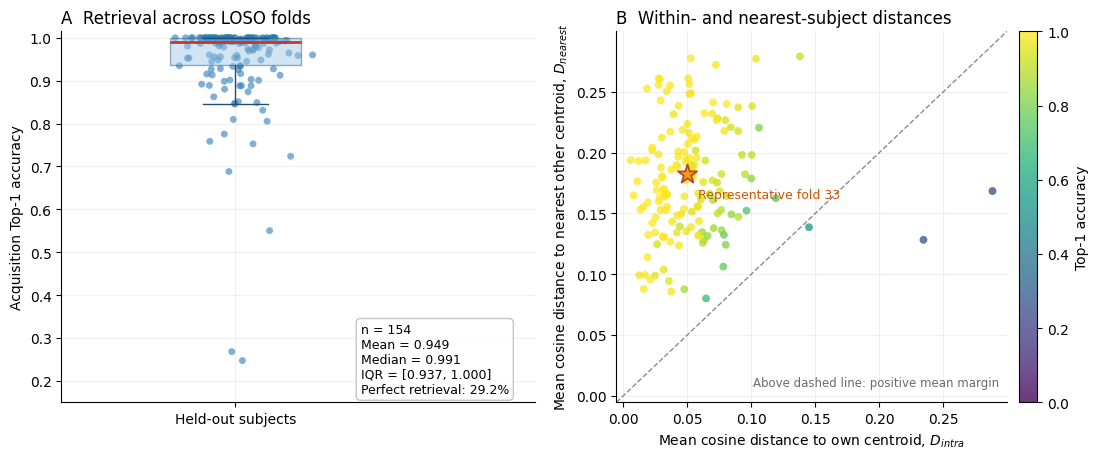

PosixPath('results/figures/stage1/full_grid_fold_metrics.png')

In [4]:
values = df['top1'].to_numpy()
q1, median_top1, q3 = np.quantile(values, [0.25, 0.50, 0.75])
perfect_rate = np.mean(np.isclose(values, 1.0))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))

# A — distribution across held-out subjects
rng = np.random.default_rng(2026)
x0 = 1.0
axes[0].scatter(
    rng.normal(x0, 0.045, len(values)), values, s=25, alpha=0.58,
    color='#2878B5', edgecolors='none',
)
axes[0].boxplot(
    values, positions=[x0], widths=0.24, showfliers=False, patch_artist=True,
    boxprops={'facecolor': '#9CC4E4', 'alpha': 0.45, 'edgecolor': '#1F4E79'},
    medianprops={'color': '#C0392B', 'linewidth': 2},
    whiskerprops={'color': '#1F4E79'},
    capprops={'color': '#1F4E79'},
)
display_lower = max(0.0, np.floor((values.min() - 0.05) * 20) / 20)
stats_text = (
    f'n = {len(values)}\n'
    f'Mean = {values.mean():.3f}\n'
    f'Median = {median_top1:.3f}\n'
    f'IQR = [{q1:.3f}, {q3:.3f}]\n'
    f'Perfect retrieval: {perfect_rate:.1%}'
)
axes[0].text(
    1.23, display_lower + 0.015, stats_text, va='bottom', ha='left', fontsize=9,
    bbox={'boxstyle': 'round,pad=0.35', 'facecolor': 'white', 'edgecolor': '0.75', 'alpha': 0.9},
)
axes[0].set_xlim(0.68, 1.55)
axes[0].set_ylim(display_lower, 1.015)
axes[0].set_xticks([1.0], ['Held-out subjects'])
axes[0].set_ylabel('Acquisition Top-1 accuracy')
axes[0].set_title('A  Retrieval across LOSO folds', loc='left')

# B — within-subject compactness versus nearest-subject separation
x = df['intra_distance_mean'].to_numpy()
y = df['nearest_inter_distance_mean'].to_numpy()
scatter = axes[1].scatter(
    x, y, c=values, cmap='viridis', vmin=0, vmax=1, s=32, alpha=0.78, edgecolors='none',
)
all_distances = np.concatenate([x, y])
lo, hi = all_distances.min(), all_distances.max()
padding = 0.04 * (hi - lo)
line_lo, line_hi = lo - padding, hi + padding
axes[1].plot([line_lo, line_hi], [line_lo, line_hi], '--', color='0.55', linewidth=1)

rep_x = representative['intra_distance_mean']
rep_y = representative['nearest_inter_distance_mean']
axes[1].scatter(
    [rep_x], [rep_y], marker='*', s=210, color='#F39C12',
    edgecolor='#C0392B', linewidth=1.2, zorder=5,
)
axes[1].annotate(
    f"Representative fold {int(representative['fold'])}",
    (rep_x, rep_y), xytext=(8, -17), textcoords='offset points',
    color='#D35400', fontsize=9,
)
axes[1].text(
    0.98, 0.035, 'Above dashed line: positive mean margin',
    transform=axes[1].transAxes, ha='right', va='bottom', fontsize=8.5, color='0.42',
)
axes[1].set_xlim(line_lo, line_hi)
axes[1].set_ylim(line_lo, line_hi)
axes[1].set_xlabel(r'Mean cosine distance to own centroid, $D_{intra}$')
axes[1].set_ylabel(r'Mean cosine distance to nearest other centroid, $D_{nearest}$')
axes[1].set_title('B  Within- and nearest-subject distances', loc='left')
colorbar = fig.colorbar(scatter, ax=axes[1], pad=0.025)
colorbar.set_label('Top-1 accuracy')

for ax in axes:
    ax.grid(alpha=0.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
output_path = FIGURE_DIR / 'full_grid_fold_metrics.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
output_path